In [1]:
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import pandas as pd
from statannotations.Annotator import Annotator
import scipy.stats as stats
import numpy as np
%matplotlib inline
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

import warnings
warnings.filterwarnings('ignore')

In [2]:
#import dataframes

#import MZmine feature table
ftable_mzmine = pd.read_csv('/home/helena/plantmasst/Diet_examples/American_vs_Mediterranean/Beef_ConjBA_iimn_quant.csv', sep=';', index_col=0)
#import the combined plantmasst table and filter for cosine_raw>=0.7
plantmasst = pd.read_csv('/home/helena/plantmasst/Diet_examples/American_vs_Mediterranean/combined_tables/American_Mediterranean_plantMASST_matches.tsv', sep='\t')
plantmasst = plantmasst[plantmasst['Cosine'] >= 0.7]
plantmasst = plantmasst[(plantmasst['Delta Mass'] >= -0.02) & (plantmasst['Delta Mass'] <= 0.02)]

#import the metadata of the study
metadata = pd.read_csv('/home/helena/plantmasst/Diet_examples/American_vs_Mediterranean/Patterson_metadata.csv', sep=';')
#import a dataframe with features with MS2
features_ms2 = pd.read_csv('/home/helena/plantmasst/Diet_examples/American_vs_Mediterranean/features_ms2.tsv', sep='\t')

#get the plantMASST taxonomy information
plantmasst_raw = plantmasst.copy()
plantmasst_full = pd.read_csv('/home/helena/plantmasst/plant_masst_table_07jan2026.csv', sep=',')
plantmasst_taxonomy = pd.read_csv('/home/helena/plantmasst/plant_masst_table_updated_07jan2026_lineage_treeR.tsv', sep='\t')
plantmasst_taxonomy = plantmasst_taxonomy.rename(columns={'TaxID': 'Taxa_NCBI'})
plantmasst_taxonomy['Taxa_NCBI'] = plantmasst_taxonomy['Taxa_NCBI'].astype(str)


In [3]:
from statsmodels.stats.multitest import multipletests

def prepare_family_data(family):
    """Identical pipeline to run_family_analysis, but WITHOUT plotting."""
    family_plantmasst = load_family_plantmasst(plantmasst_raw, family, plantmasst_full, plantmasst_taxonomy)
    summed_df_merged = preprocess_and_analyze_abundance(ftable_mzmine, family_plantmasst, metadata, features_ms2)
    summed_df_merged = summed_df_merged.fillna('NA')
    summed_df_merged = summed_df_merged[summed_df_merged['diet'] != 'NA']
    summed_df_merged = summed_df_merged[summed_df_merged['TREAT'].isin(['AAD', 'MED0.5', 'MED2.5', 'MED5.5'])] ## consider all the MED groups
    summed_df_merged = summed_df_merged[summed_df_merged['MS_type'] != 'ddMS2_pos']
    summed_df_merged = summed_df_merged[summed_df_merged['diet'] != 'Baseline']
    order = ['American', 'Mediterranean']
    summed_df_merged['diet'] = pd.Categorical(summed_df_merged['diet'], categories=order, ordered=True)
    summed_df_merged = summed_df_merged.sort_values('diet')
    summed_df_merged = remove_outliers(summed_df_merged, group_col='diet', value_col='percentage')
    return summed_df_merged


def load_family_plantmasst(plantmasst_raw, family, plantmasst_full, plantmasst_taxonomy):
    family_plantmasst = plantmasst_raw[plantmasst_raw['Filepath'].isin(plantmasst_full['Filepath'])].copy()
    family_plantmasst = family_plantmasst.drop(columns=['family'], errors='ignore')
    family_plantmasst['Taxa_NCBI'] = family_plantmasst['Taxa_NCBI'].astype(str).str.strip()
    plantmasst_taxonomy = plantmasst_taxonomy.copy()
    plantmasst_taxonomy['Taxa_NCBI'] = plantmasst_taxonomy['Taxa_NCBI'].astype(str).str.strip()
    family_plantmasst = pd.merge(
        family_plantmasst,
        plantmasst_taxonomy[['Taxa_NCBI', 'family']],
        on='Taxa_NCBI',
        how='left',
    )
    family_plantmasst['family'] = family_plantmasst['family'].astype(str).str.strip()
    return family_plantmasst[family_plantmasst['family'].isin([family])]

def preprocess_and_analyze_abundance(ftable_mzmine, plantmasst_family, metadata, features_ms2):
    ftable_mzmine = ftable_mzmine[ftable_mzmine.index.isin(features_ms2['row ID'])].copy()
    plantmasst_filtered = plantmasst_family[
        (plantmasst_family.Blank != 'Yes')
        & (plantmasst_family.QC != 'Yes')
        & (plantmasst_family.MassIVE != 'MSV000083756')
    ]

    valid_scans = set(plantmasst_filtered['Scan'])
    new_columns = {}

    for column in ftable_mzmine.columns:
        column_name_temp = f'{column}_plantmasst'
        new_column = pd.Series(0, index=ftable_mzmine.index)
        matching_rows = (ftable_mzmine[column] != 0) & ftable_mzmine.index.isin(valid_scans)
        new_column[matching_rows] = ftable_mzmine[column]
        new_columns[column_name_temp] = new_column

    ftable_mzmine = pd.concat([ftable_mzmine, pd.DataFrame(new_columns)], axis=1)
    sums = ftable_mzmine.sum(axis=0)
    summed_df = pd.DataFrame({'filename': sums.index, 'total_features': sums.values})
    summed_df['plantmasst_features'] = summed_df['filename'].apply(
        lambda x: summed_df.loc[summed_df['filename'] == f'{x}_plantmasst', 'total_features'].sum()
    )
    summed_df = summed_df[~summed_df['filename'].str.contains('_plantmasst')].reset_index(drop=True)
    summed_df['percentage'] = summed_df['plantmasst_features'] / summed_df['total_features'] * 100
    return pd.merge(summed_df, metadata, on='filename', how='left')

def remove_outliers(df, group_col, value_col):
    filtered_groups = []
    for group in df[group_col].dropna().unique():
        group_data = df[df[group_col] == group]
        q1 = np.percentile(group_data[value_col], 25)
        q3 = np.percentile(group_data[value_col], 75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        filtered_groups.append(
            group_data[
                (group_data[value_col] >= lower_bound)
                & (group_data[value_col] <= upper_bound)
]
        )
    return pd.concat(filtered_groups, ignore_index=False)

In [4]:
# Every family that appears in the taxonomy for the plantMASST matches in THIS dataset.
# This mirrors what load_family_plantmasst does, but without filtering to one family,
# so we get the universe of families to test.
_pm = plantmasst_raw[plantmasst_raw['Filepath'].isin(plantmasst_full['Filepath'])].copy()
_pm = _pm.drop(columns=['family'], errors='ignore')
_pm['Taxa_NCBI'] = _pm['Taxa_NCBI'].astype(str).str.strip()

_tax = plantmasst_taxonomy.copy()
_tax['Taxa_NCBI'] = _tax['Taxa_NCBI'].astype(str).str.strip()

_pm = pd.merge(_pm, _tax[['Taxa_NCBI', 'family']], on='Taxa_NCBI', how='left')
_pm['family'] = _pm['family'].astype(str).str.strip()

all_families = sorted(f for f in _pm['family'].unique()
                      if f not in ('nan', 'NA', '', 'None'))
print(f"{len(all_families)} families found")
print(all_families[:20])

260 families found
['Acanthaceae', 'Achatocarpaceae', 'Actinidiaceae', 'Adoxaceae', 'Aizoaceae', 'Alismataceae', 'Alstroemeriaceae', 'Altingiaceae', 'Amaranthaceae', 'Amaryllidaceae', 'Anacampserotaceae', 'Anacardiaceae', 'Annonaceae', 'Apiaceae', 'Apocynaceae', 'Aquifoliaceae', 'Araceae', 'Araliaceae', 'Arecaceae', 'Aristolochiaceae']


In [7]:
import statsmodels.formula.api as smf

def mixed_p_family(df):
    m = smf.mixedlm('percentage ~ C(diet)', df, groups=df['SampleID']).fit()
    coef = [k for k in m.pvalues.index if 'Mediterranean' in k][0]
    return m.params[coef], m.pvalues[coef]

records = []
for fam in families:
    df = prepare_family_data(fam)
    if df['diet'].nunique() < 2 or df['SampleID'].nunique() < 3:
        continue
    try:
        coef, pval = mixed_p_family(df)
    except Exception as e:
        print(f'Skipping {fam}: {e}')
        continue
    if np.isnan(pval):
        continue
    records.append({'family': fam, 'diet_coef': coef, 'p_value': pval,
                    'n_obs': len(df), 'n_subjects': df['SampleID'].nunique()})

fdr_table = pd.DataFrame(records)
fdr_table['q_value'] = multipletests(fdr_table['p_value'], method='fdr_bh')[1]

In [8]:
import numpy as np
from statsmodels.stats.multitest import multipletests

# rows with a usable p-value (the 16 NaN families get excluded from correction)
valid = fdr_table['p_value'].notna() & (fdr_table['p_value'] >= 0) & (fdr_table['p_value'] <= 1)
print(f"valid p-values: {valid.sum()} of {len(fdr_table)}  (dropping {(~valid).sum()})")

# BH-FDR on valid rows only; NaN families stay NaN
fdr_table['q_value'] = np.nan
fdr_table.loc[valid, 'q_value'] = multipletests(
    fdr_table.loc[valid, 'p_value'], method='fdr_bh'
)[1]

fdr_table = fdr_table.sort_values('p_value').reset_index(drop=True)

# what your letter depends on
print(f"Survive FDR q<0.05: {(fdr_table['q_value'] < 0.05).sum()}")
print(f"Min q: {fdr_table['q_value'].min():.4f}")
print()
print("=== Oleaceae & Fabaceae ===")
print(fdr_table[fdr_table['family'].isin(['Oleaceae','Fabaceae'])]
      [['family','diet_coef','p_value','q_value','n_obs','n_subjects']].to_string(index=False))

valid p-values: 244 of 244  (dropping 0)
Survive FDR q<0.05: 60
Min q: 0.0009

=== Oleaceae & Fabaceae ===
  family  diet_coef  p_value  q_value  n_obs  n_subjects
Oleaceae   0.099256 0.005219 0.031058    107          29
Fabaceae   0.174948 0.060634 0.132095    104          29


In [15]:
fdr_table.to_csv('/home/helena/Python_scripts/plantMASST/Scripts_manusript_R1/R2_FDR_boxplots/fdr_table.tsv', sep='\t', index=False)

# Boxplots

American vs. Mediterranean: p = 0.321


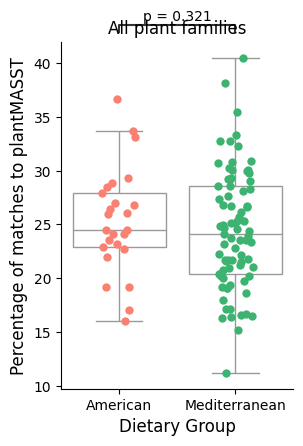

Overall: p = 0.3215 | n=106, subjects=29
American vs. Mediterranean: q = 0.031


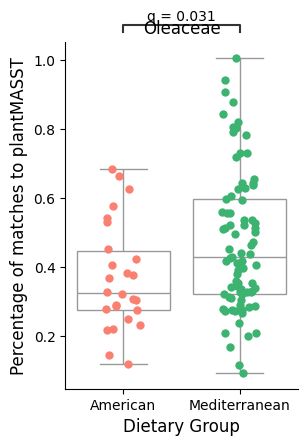

Oleaceae: p = 0.0052, q = 0.0311 | n=107, subjects=29
American vs. Mediterranean: q = 0.132


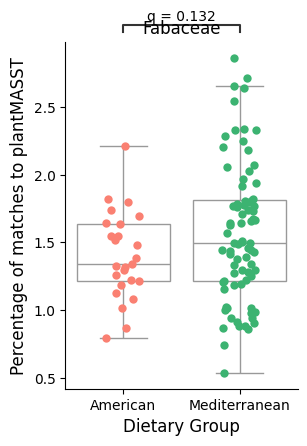

Fabaceae: p = 0.0606, q = 0.1321 | n=104, subjects=29


In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from statannotations.Annotator import Annotator


def _style_boxplot(ax, df, order, my_pal):
    """Apply your original per-diet coloring of box lines/edges."""
    for i, artist in enumerate(ax.artists):
        color = my_pal[df['diet'].unique()[i]]
        artist.set_edgecolor(color)
        for j in range(i * 5, i * 5 + 5):
            line = ax.lines[j]
            line.set_color(color); line.set_mfc(color); line.set_mec(color)


def make_diet_boxplot(df, annotation, title, savepath=None):
    """df: prepared data (diet in {American, Mediterranean}); annotation: string to show on the bracket."""
    order = ['American', 'Mediterranean']
    my_pal = {'Mediterranean': 'mediumseagreen', 'American': 'salmon'}

    plt.figure(figsize=(3, 4.5))
    ax = sns.boxplot(x='diet', y='percentage', data=df, order=order,
                     notch=False, showfliers=False,
                     palette={'Mediterranean': 'white', 'American': 'white'})
    for diet_name in df['diet'].dropna().unique():
        sns.stripplot(x='diet', y='percentage',
                      data=df[df['diet'] == diet_name],
                      color=my_pal[diet_name], jitter=0.15, size=6, ax=ax)

    annotator = Annotator(ax, [('American', 'Mediterranean')],
                          data=df, x='diet', y='percentage', order=order)
    annotator.configure(text_format='simple', loc='outside')
    annotator.set_custom_annotations([annotation])
    annotator.annotate()

    plt.xlabel('Dietary Group', size=12)
    plt.ylabel('Percentage of matches to plantMASST', size=12)
    _style_boxplot(ax, df, order, my_pal)
    sns.despine()
    ax.spines['right'].set_visible(False); ax.spines['top'].set_visible(False)
    plt.title(title, size=12)
    if savepath:
        plt.savefig(savepath, format='pdf', bbox_inches='tight')
    plt.show()

def prepare_all_plants_data(treat_groups=('AAD', 'MED0.5', 'MED2.5', 'MED5.5')):
    """All-plants version of prepare_family_data: no family filter.
    Uses the same four-arg preprocessing as the family analysis (keeps features_ms2),
    but feeds it the full plantMASST table so every family counts."""
    all_plantmasst = plantmasst_raw[plantmasst_raw['Filepath'].isin(plantmasst_full['Filepath'])].copy()

    summed = preprocess_and_analyze_abundance(ftable_mzmine, all_plantmasst, metadata, features_ms2)
    summed = summed.fillna('NA')
    summed = summed[summed['diet'] != 'NA']
    summed = summed[summed['TREAT'].isin(treat_groups)]
    summed = summed[summed['MS_type'] != 'ddMS2_pos']
    summed = summed[summed['diet'] != 'Baseline']
    order = ['American', 'Mediterranean']
    summed['diet'] = pd.Categorical(summed['diet'], categories=order, ordered=True)
    summed = summed.sort_values('diet')
    summed = remove_outliers(summed, group_col='diet', value_col='percentage')
    return summed

def mixed_p(df):
    """Raw mixed-model American-vs-Mediterranean p-value for a prepared dataframe."""
    m = smf.mixedlm('percentage ~ C(diet)', df, groups=df['SampleID']).fit()
    coef = [k for k in m.pvalues.index if 'Mediterranean' in k][0]
    return m.pvalues[coef]


# ---- 1. OVERALL: all plant families, raw mixed-model p ----
df_overall = prepare_all_plants_data()          # from earlier: no family filter, full MED group
p_overall = mixed_p(df_overall)
make_diet_boxplot(df_overall, f"p = {p_overall:.3f}", "All plant families",
                  savepath='/home/helena/Python_scripts/plantMASST/Scripts_manusript_R1/R2_FDR_boxplots/all_plant_families_boxplot.pdf')   
print(f"Overall: p = {p_overall:.4f} | n={len(df_overall)}, subjects={df_overall['SampleID'].nunique()}")


# ---- 2 & 3. FAMILIES: show FDR-corrected q from fdr_table ----
for fam in ['Oleaceae', 'Fabaceae']:
    df_fam = prepare_family_data(fam)            # full MED group
    row = fdr_table.loc[fdr_table['family'] == fam].iloc[0]
    # annotate with the corrected q-value (what the manuscript reports)
    annotation = f"q = {row['q_value']:.3f}"
    make_diet_boxplot(df_fam, annotation, fam,
                      savepath=f'/home/helena/Python_scripts/plantMASST/Scripts_manusript_R1/R2_FDR_boxplots/{fam}_boxplot.pdf')   # e.g. f'fig2e_{fam}.pdf'
    print(f"{fam}: p = {row['p_value']:.4f}, q = {row['q_value']:.4f} | "
          f"n={len(df_fam)}, subjects={df_fam['SampleID'].nunique()}")

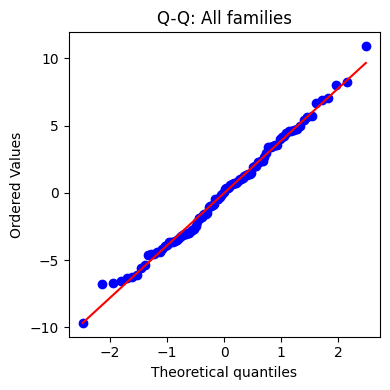

All families         Shapiro W=0.993, p=0.864 | n=106, RE var=10.93


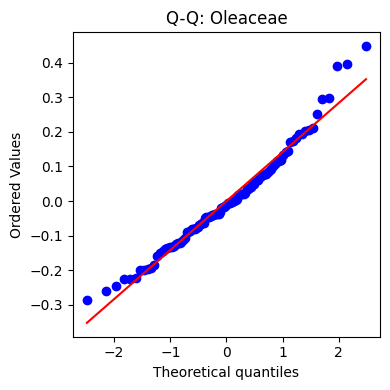

Oleaceae             Shapiro W=0.972, p=0.023 | n=107, RE var=0.01394


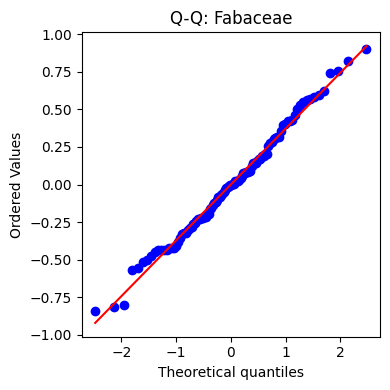

Fabaceae             Shapiro W=0.990, p=0.625 | n=104, RE var=0.0638


In [12]:
import statsmodels.formula.api as smf
import scipy.stats as stats
import matplotlib.pyplot as plt

def check_residuals(prepared_df, label):
    """Fit the reported mixed model and inspect its residuals."""
    m = smf.mixedlm('percentage ~ C(diet)', prepared_df,
                    groups=prepared_df['SampleID']).fit()
    resid = m.resid

    # Q-Q plot
    fig = plt.figure(figsize=(4, 4))
    stats.probplot(resid, dist="norm", plot=plt)
    plt.title(f"Q-Q: {label}")
    plt.tight_layout()
    plt.show()

    # Shapiro-Wilk (tests H0 = normal; p > 0.05 = no evidence against normality)
    W, p = stats.shapiro(resid)
    re_var = float(m.cov_re.iloc[0, 0])   # random-intercept variance
    print(f"{label:20s} Shapiro W={W:.3f}, p={p:.3f} | "
          f"n={len(resid)}, RE var={re_var:.4g}")
    return m

# Fit and check EACH model the paper reports
m_overall = check_residuals(prepare_all_plants_data(), "All families")
m_ole     = check_residuals(prepare_family_data('Oleaceae'), "Oleaceae")
m_fab     = check_residuals(prepare_family_data('Fabaceae'), "Fabaceae")